In [2]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class JigsawPreprocessor:
    """
    Preprocessor for Jigsaw Unintended Bias in Toxicity Classification dataset
    """
    
    def __init__(self):
        self.identity_columns = [
            'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
            'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'asian',
            'atheist', 'bisexual', 'buddhist', 'heterosexual', 'hindu',
            'intellectual_or_learning_disability', 'latino', 'other_disability',
            'other_gender', 'other_race_or_ethnicity', 'other_religion',
            'other_sexual_orientation', 'physical_disability', 'transgender'
        ]
        
        self.toxicity_subtypes = [
            'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat'
        ]
        
    def load_data(self, train_path, test_path):
        """Load train and test datasets"""
        print("Loading datasets...")
        self.train_df = pd.read_csv(train_path)
        self.test_df = pd.read_csv(test_path)
        print(f"Train shape: {self.train_df.shape}")
        print(f"Test shape: {self.test_df.shape}")
        return self.train_df, self.test_df
    
    def clean_text(self, text):
        """Clean and normalize text"""
        if pd.isna(text):
            return ""
        
        # Convert to string and lowercase
        text = str(text).lower()
        
        # Remove newlines and tabs
        text = text.replace('\n', ' ').replace('\t', ' ')
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        
        # Remove special characters but keep punctuation that might be important
        text = re.sub(r'[^a-zA-Z0-9\s\.\!\?\,]', ' ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def handle_missing_values(self, df, is_train=True):
        """Handle missing values in the dataset"""
        print("\nHandling missing values...")
        
        # For comment_text, fill with empty string
        df['comment_text'] = df['comment_text'].fillna('')
        
        if is_train:
            # Fill target with median (though it should not have missing values)
            if df['target'].isna().any():
                df['target'] = df['target'].fillna(df['target'].median())
            
            # Fill toxicity subtypes with 0 (assuming no annotation means not toxic)
            for col in self.toxicity_subtypes:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
            
            # Fill identity columns with 0 (no mention)
            for col in self.identity_columns:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
            
            # Fill other numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if df[col].isna().any():
                    df[col] = df[col].fillna(0)
        
        return df
    
    def create_target_labels(self, df):
        """Create binary target labels for classification"""
        print("\nCreating target labels...")
        
        # Binary classification: toxic (>=0.5) vs non-toxic (<0.5)
        df['target_binary'] = (df['target'] >= 0.5).astype(int)
        
        # Create multi-label targets for toxicity subtypes
        for col in self.toxicity_subtypes:
            if col in df.columns:
                df[f'{col}_binary'] = (df[col] >= 0.5).astype(int)
        
        return df
    
    def create_identity_features(self, df):
        """Create aggregated identity features"""
        print("\nCreating identity features...")
        
        # Check if any identity is mentioned
        identity_cols_present = [col for col in self.identity_columns if col in df.columns]
        
        if identity_cols_present:
            df['any_identity'] = (df[identity_cols_present] >= 0.5).any(axis=1).astype(int)
            df['identity_count'] = (df[identity_cols_present] >= 0.5).sum(axis=1)
        
        return df
    
    def create_text_features(self, df):
        """Create basic text-based features"""
        print("\nCreating text features...")
        
        df['text_length'] = df['comment_text'].apply(len)
        df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))
        df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(str(x).split())))
        df['char_count'] = df['comment_text'].apply(lambda x: len(str(x)))
        df['punctuation_count'] = df['comment_text'].apply(lambda x: sum([1 for c in str(x) if c in string.punctuation]))
        df['capital_count'] = df['comment_text'].apply(lambda x: sum([1 for c in str(x) if c.isupper()]))
        df['exclamation_count'] = df['comment_text'].apply(lambda x: str(x).count('!'))
        df['question_count'] = df['comment_text'].apply(lambda x: str(x).count('?'))
        
        # Average word length
        df['avg_word_length'] = df['comment_text'].apply(
            lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
        )
        
        return df
    
    def remove_irrelevant_columns(self, df, is_train=True):
        """Remove columns that are not useful for modeling"""
        print("\nRemoving irrelevant columns...")
        
        cols_to_drop = []
        
        # Metadata columns that won't help with toxicity prediction
        metadata_cols = ['created_date', 'publication_id', 'parent_id', 'article_id']
        for col in metadata_cols:
            if col in df.columns:
                cols_to_drop.append(col)
        
        # Engagement metrics (rating, funny, wow, sad, likes, disagree)
        # These might be outcomes rather than predictors
        engagement_cols = ['rating', 'funny', 'wow', 'sad', 'likes', 'disagree']
        for col in engagement_cols:
            if col in df.columns:
                cols_to_drop.append(col)
        
        # Annotator counts - keep these as they might indicate agreement/uncertainty
        # annotator_cols = ['identity_annotator_count', 'toxicity_annotator_count']
        
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop, errors='ignore')
            print(f"Dropped columns: {cols_to_drop}")
        
        return df
    
    def preprocess(self, train_path, test_path, sample_size=None):
        """
        Complete preprocessing pipeline
        
        Args:
            train_path: Path to training CSV
            test_path: Path to test CSV
            sample_size: If provided, use a sample of training data for faster processing
        
        Returns:
            train_df, test_df: Preprocessed dataframes
        """
        # Load data
        train_df, test_df = self.load_data(train_path, test_path)
        
        # Sample if requested (useful for development)
        if sample_size and sample_size < len(train_df):
            print(f"\nSampling {sample_size} rows from training data...")
            train_df = train_df.sample(n=sample_size, random_state=42)
        
        # Clean text
        print("\nCleaning text...")
        train_df['comment_text_clean'] = train_df['comment_text'].apply(self.clean_text)
        test_df['comment_text_clean'] = test_df['comment_text'].apply(self.clean_text)
        
        # Handle missing values
        train_df = self.handle_missing_values(train_df, is_train=True)
        test_df = self.handle_missing_values(test_df, is_train=False)
        
        # Create target labels (only for train)
        train_df = self.create_target_labels(train_df)
        
        # Create identity features
        train_df = self.create_identity_features(train_df)
        test_df = self.create_identity_features(test_df)
        
        # Create text features
        train_df = self.create_text_features(train_df)
        test_df = self.create_text_features(test_df)
        
        # Remove irrelevant columns
        train_df = self.remove_irrelevant_columns(train_df, is_train=True)
        test_df = self.remove_irrelevant_columns(test_df, is_train=False)
        
        print("\n" + "="*50)
        print("PREPROCESSING COMPLETE")
        print("="*50)
        print(f"\nFinal train shape: {train_df.shape}")
        print(f"Final test shape: {test_df.shape}")
        
        # Show class distribution
        if 'target_binary' in train_df.columns:
            print(f"\nTarget distribution:")
            print(train_df['target_binary'].value_counts(normalize=True))
        
        return train_df, test_df
    
    def save_processed_data(self, train_df, test_df, output_dir='./'):
        """Save preprocessed data"""
        print("\nSaving preprocessed data...")
        train_df.to_csv(f'{output_dir}train_preprocessed.csv', index=False)
        test_df.to_csv(f'{output_dir}test_preprocessed.csv', index=False)
        print("Data saved successfully!")


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Initialize preprocessor
    preprocessor = JigsawPreprocessor()
    
    # Define file paths (adjust these to your Kaggle notebook paths)
    train_path = '/kaggle/input/toxicity2/train.csv'
    test_path = '/kaggle/input/toxicity2/test.csv'
    
    # Preprocess data
    # Use sample_size parameter for quick testing (e.g., sample_size=10000)
    # Remove or set to None for full dataset
    train_processed, test_processed = preprocessor.preprocess(
        train_path=train_path,
        test_path=test_path,
        sample_size=None  # Set to a smaller number for testing, e.g., 50000
    )
    
    # Save processed data
    preprocessor.save_processed_data(train_processed, test_processed)
    
    # Display info
    print("\nTrain columns:", train_processed.columns.tolist())
    print("\nFirst few rows of processed training data:")
    print(train_processed.head())
    
    print("\n" + "="*50)
    print("KEY COLUMNS FOR MODELING")
    print("="*50)
    print("\nText column: 'comment_text_clean'")
    print("Target column: 'target_binary' (0=non-toxic, 1=toxic)")
    print("Original target: 'target' (continuous 0-1)")
    print("\nIdentity columns available:", preprocessor.identity_columns)
    print("Toxicity subtype columns:", preprocessor.toxicity_subtypes) 

Loading datasets...
Train shape: (1804874, 45)
Test shape: (97320, 2)

Cleaning text...

Handling missing values...

Handling missing values...

Creating target labels...

Creating identity features...

Creating identity features...

Creating text features...

Creating text features...

Removing irrelevant columns...
Dropped columns: ['created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree']

Removing irrelevant columns...

PREPROCESSING COMPLETE

Final train shape: (1804874, 53)
Final test shape: (97320, 12)

Target distribution:
target_binary
0    0.920031
1    0.079969
Name: proportion, dtype: float64

Saving preprocessed data...
Data saved successfully!

Train columns: ['id', 'target', 'comment_text', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_dis

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

class TFRDConfig:
    """Configuration for TFRD model"""
    
    # Model Architecture
    TEACHER_MODEL = 'bert-base-uncased'  # Teacher model for distillation
    STUDENT_MODEL = 'huawei-noah/TinyBERT_General_4L_312D'  # TinyBERT student
    MAX_LENGTH = 256
    HIDDEN_SIZE = 312  # TinyBERT hidden size
    DROPOUT = 0.3
    
    # Training Parameters
    BATCH_SIZE = 32
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 3
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    MAX_GRAD_NORM = 1.0
    
    # Distillation Parameters
    TEMPERATURE = 4.0  # Temperature for knowledge distillation
    ALPHA_DISTILL = 0.5  # Weight for distillation loss
    ALPHA_TASK = 0.3  # Weight for task loss
    ALPHA_FAIRNESS = 0.2  # Weight for fairness regularization
    
    # Fairness Parameters
    IDENTITY_THRESHOLD = 0.5  # Threshold for identity mention
    FAIRNESS_LAMBDA = 0.1  # Strength of fairness constraint
    
    # Data Parameters
    VAL_SPLIT = 0.1
    SAMPLE_SIZE = 50000  # Set to integer for testing (e.g., 50000)
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Paths
    TRAIN_PATH = '/kaggle/working/train_preprocessed.csv'
    TEST_PATH = '/kaggle/working/test_preprocessed.csv'
    OUTPUT_DIR = '/kaggle/working/'
    
    # Identity columns for fairness
    IDENTITY_COLUMNS = [
        'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
        'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'asian',
        'atheist', 'bisexual', 'buddhist', 'heterosexual', 'hindu',
        'intellectual_or_learning_disability', 'latino', 'other_disability',
        'other_gender', 'other_race_or_ethnicity', 'other_religion',
        'other_sexual_orientation', 'physical_disability', 'transgender'
    ]


# =============================================================================
# DATASET CLASS
# =============================================================================

class ToxicityDataset(Dataset):
    """Dataset for toxicity classification with identity information"""
    
    def __init__(self, texts, labels, identity_labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.identity_labels = identity_labels  # Binary indicators for identity mentions
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        identity = self.identity_labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float),
            'identity': torch.tensor(identity, dtype=torch.float)
        }


# =============================================================================
# FAIRNESS REGULARIZATION
# =============================================================================

class FairnessRegularizer:
    """
    Implements fairness regularization to reduce bias across identity groups
    Based on equalized odds and demographic parity principles
    """
    
    def __init__(self, lambda_fair=0.1):
        self.lambda_fair = lambda_fair
    
    def compute_fairness_loss(self, predictions, labels, identities):
        """
        Compute fairness loss to encourage similar performance across identity groups
        
        Args:
            predictions: Model predictions (logits or probabilities)
            labels: True labels
            identities: Binary indicators for identity mentions
        
        Returns:
            fairness_loss: Scalar tensor
        """
        # Separate samples with and without identity mentions
        identity_mask = identities > 0.5
        non_identity_mask = ~identity_mask
        
        # If no samples in one group, return zero loss
        if identity_mask.sum() == 0 or non_identity_mask.sum() == 0:
            return torch.tensor(0.0, device=predictions.device)
        
        # Get predictions for each group
        pred_identity = predictions[identity_mask]
        pred_non_identity = predictions[non_identity_mask]
        
        # Get labels for each group
        label_identity = labels[identity_mask]
        label_non_identity = labels[non_identity_mask]
        
        # Compute false positive rates (FPR) for each group
        # FPR = FP / (FP + TN)
        fpr_identity = self._compute_fpr(pred_identity, label_identity)
        fpr_non_identity = self._compute_fpr(pred_non_identity, label_non_identity)
        
        # Compute false negative rates (FNR) for each group
        # FNR = FN / (FN + TP)
        fnr_identity = self._compute_fnr(pred_identity, label_identity)
        fnr_non_identity = self._compute_fnr(pred_non_identity, label_non_identity)
        
        # Fairness loss: minimize difference in error rates between groups
        fairness_loss = (
            torch.abs(fpr_identity - fpr_non_identity) +
            torch.abs(fnr_identity - fnr_non_identity)
        )
        
        return self.lambda_fair * fairness_loss
    
    def _compute_fpr(self, predictions, labels):
        """Compute False Positive Rate"""
        preds_binary = (predictions > 0.5).float()
        negatives = (labels == 0).float()
        
        if negatives.sum() == 0:
            return torch.tensor(0.0, device=predictions.device)
        
        false_positives = ((preds_binary == 1) & (labels == 0)).float().sum()
        fpr = false_positives / negatives.sum()
        return fpr
    
    def _compute_fnr(self, predictions, labels):
        """Compute False Negative Rate"""
        preds_binary = (predictions > 0.5).float()
        positives = (labels == 1).float()
        
        if positives.sum() == 0:
            return torch.tensor(0.0, device=predictions.device)
        
        false_negatives = ((preds_binary == 0) & (labels == 1)).float().sum()
        fnr = false_negatives / positives.sum()
        return fnr


# =============================================================================
# TFRD MODEL
# =============================================================================

class TFRDModel(nn.Module):
    """
    TinyBERT with Fairness-Regularized Distillation
    
    Architecture:
    - TinyBERT as student model (compressed BERT)
    - Knowledge distillation from BERT teacher
    - Fairness regularization layer
    - Classification head with dropout
    """
    
    def __init__(self, config):
        super(TFRDModel, self).__init__()
        self.config = config
        
        # Load TinyBERT
        self.bert = AutoModel.from_pretrained(config.STUDENT_MODEL)
        
        # Classification head
        self.dropout = nn.Dropout(config.DROPOUT)
        self.classifier = nn.Linear(config.HIDDEN_SIZE, 1)
        
        # Initialize weights
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)
    
    def forward(self, input_ids, attention_mask):
        """
        Forward pass
        
        Args:
            input_ids: Token IDs
            attention_mask: Attention mask
        
        Returns:
            logits: Raw predictions
            hidden_states: Last hidden state from BERT
        """
        # Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        # Use [CLS] token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
        
        # Classification
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)  # [batch_size, 1]
        
        return logits, outputs.hidden_states


# =============================================================================
# TEACHER MODEL (for Knowledge Distillation)
# =============================================================================

class TeacherModel(nn.Module):
    """BERT Teacher model for knowledge distillation"""
    
    def __init__(self, model_name='bert-base-uncased'):
        super(TeacherModel, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, 1)  # BERT-base hidden size is 768
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        return logits, outputs.hidden_states


# =============================================================================
# DISTILLATION LOSS
# =============================================================================

class DistillationLoss:
    """Knowledge distillation loss with temperature scaling"""
    
    def __init__(self, temperature=4.0):
        self.temperature = temperature
        self.kl_div = nn.KLDivLoss(reduction='batchmean')
    
    def compute_loss(self, student_logits, teacher_logits):
        """
        Compute distillation loss using KL divergence
        
        Args:
            student_logits: Logits from student model
            teacher_logits: Logits from teacher model (detached)
        
        Returns:
            distillation_loss: Scalar tensor
        """
        # Apply temperature scaling and softmax
        student_probs = F.log_softmax(student_logits / self.temperature, dim=-1)
        teacher_probs = F.softmax(teacher_logits / self.temperature, dim=-1)
        
        # KL divergence loss
        loss = self.kl_div(student_probs, teacher_probs) * (self.temperature ** 2)
        
        return loss


# =============================================================================
# TRAINER
# =============================================================================

class TFRDTrainer:
    """Trainer for TFRD model with distillation and fairness regularization"""
    
    def __init__(self, config):
        self.config = config
        self.device = config.DEVICE
        
        # Initialize tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(config.STUDENT_MODEL)
        
        # Initialize models
        print("Loading models...")
        self.student_model = TFRDModel(config).to(self.device)
        self.teacher_model = TeacherModel(config.TEACHER_MODEL).to(self.device)
        
        # Freeze teacher model
        for param in self.teacher_model.parameters():
            param.requires_grad = False
        self.teacher_model.eval()
        
        # Initialize loss functions
        self.task_loss_fn = nn.BCEWithLogitsLoss()
        self.distillation_loss_fn = DistillationLoss(temperature=config.TEMPERATURE)
        self.fairness_regularizer = FairnessRegularizer(lambda_fair=config.FAIRNESS_LAMBDA)
        
        # Metrics storage
        self.train_losses = []
        self.val_losses = []
        self.val_aucs = []
    
    def load_data(self):
        """Load and prepare data"""
        print("\nLoading data...")
        train_df = pd.read_csv(self.config.TRAIN_PATH)
        test_df = pd.read_csv(self.config.TEST_PATH)
        
        # Sample for faster testing if specified
        if self.config.SAMPLE_SIZE:
            train_df = train_df.sample(n=min(self.config.SAMPLE_SIZE, len(train_df)), random_state=42)
            print(f"Using sample of {len(train_df)} training examples")
        
        # Prepare identity labels (any_identity column or aggregate)
        if 'any_identity' in train_df.columns:
            train_identity = train_df['any_identity'].values
        else:
            # Aggregate identity columns
            identity_cols = [col for col in self.config.IDENTITY_COLUMNS if col in train_df.columns]
            train_identity = (train_df[identity_cols].fillna(0) >= self.config.IDENTITY_THRESHOLD).any(axis=1).astype(int).values
        
        if 'any_identity' in test_df.columns:
            test_identity = test_df['any_identity'].values
        else:
            identity_cols = [col for col in self.config.IDENTITY_COLUMNS if col in test_df.columns]
            test_identity = (test_df[identity_cols].fillna(0) >= self.config.IDENTITY_THRESHOLD).any(axis=1).astype(int).values
        
        # Split training data
        train_texts = train_df['comment_text_clean'].values
        train_labels = train_df['target_binary'].values
        
        X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
            train_texts, train_labels, train_identity,
            test_size=self.config.VAL_SPLIT,
            random_state=42,
            stratify=train_labels
        )
        
        # Create datasets
        self.train_dataset = ToxicityDataset(
            X_train, y_train, id_train, self.tokenizer, self.config.MAX_LENGTH
        )
        self.val_dataset = ToxicityDataset(
            X_val, y_val, id_val, self.tokenizer, self.config.MAX_LENGTH
        )
        self.test_dataset = ToxicityDataset(
            test_df['comment_text_clean'].values,
            np.zeros(len(test_df)),  # Dummy labels for test
            test_identity,
            self.tokenizer,
            self.config.MAX_LENGTH
        )
        
        # Create dataloaders
        self.train_loader = DataLoader(
            self.train_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
        self.val_loader = DataLoader(
            self.val_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )
        self.test_loader = DataLoader(
            self.test_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )
        
        print(f"Training samples: {len(self.train_dataset)}")
        print(f"Validation samples: {len(self.val_dataset)}")
        print(f"Test samples: {len(self.test_dataset)}")
        
        return test_df
    
    def setup_training(self):
        """Setup optimizer and scheduler"""
        # Optimizer
        no_decay = ['bias', 'LayerNorm.weight']
        optimizer_grouped_parameters = [
            {
                'params': [p for n, p in self.student_model.named_parameters() 
                          if not any(nd in n for nd in no_decay)],
                'weight_decay': self.config.WEIGHT_DECAY
            },
            {
                'params': [p for n, p in self.student_model.named_parameters() 
                          if any(nd in n for nd in no_decay)],
                'weight_decay': 0.0
            }
        ]
        
        self.optimizer = torch.optim.AdamW(
            optimizer_grouped_parameters,
            lr=self.config.LEARNING_RATE
        )
        
        # Scheduler
        total_steps = len(self.train_loader) * self.config.NUM_EPOCHS
        warmup_steps = int(total_steps * self.config.WARMUP_RATIO)
        
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
    
    def train_epoch(self, epoch):
        """Train for one epoch"""
        self.student_model.train()
        total_loss = 0
        total_task_loss = 0
        total_distill_loss = 0
        total_fair_loss = 0
        
        for batch_idx, batch in enumerate(self.train_loader):
            # Move to device
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['label'].to(self.device)
            identities = batch['identity'].to(self.device)
            
            # Forward pass - student
            student_logits, student_hidden = self.student_model(input_ids, attention_mask)
            student_logits = student_logits.squeeze(-1)
            
            # Forward pass - teacher (no gradients)
            with torch.no_grad():
                teacher_logits, teacher_hidden = self.teacher_model(input_ids, attention_mask)
                teacher_logits = teacher_logits.squeeze(-1)
            
            # Compute losses
            # 1. Task loss (BCE)
            task_loss = self.task_loss_fn(student_logits, labels)
            
            # 2. Distillation loss (KL divergence)
            # Reshape for distillation loss
            student_logits_reshaped = student_logits.unsqueeze(-1)
            teacher_logits_reshaped = teacher_logits.unsqueeze(-1)
            distill_loss = self.distillation_loss_fn.compute_loss(
                student_logits_reshaped, teacher_logits_reshaped
            )
            
            # 3. Fairness loss
            predictions = torch.sigmoid(student_logits)
            fair_loss = self.fairness_regularizer.compute_fairness_loss(
                predictions, labels, identities
            )
            
            # Combined loss
            loss = (
                self.config.ALPHA_TASK * task_loss +
                self.config.ALPHA_DISTILL * distill_loss +
                self.config.ALPHA_FAIRNESS * fair_loss
            )
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.student_model.parameters(), self.config.MAX_GRAD_NORM)
            self.optimizer.step()
            self.scheduler.step()
            
            # Track losses
            total_loss += loss.item()
            total_task_loss += task_loss.item()
            total_distill_loss += distill_loss.item()
            total_fair_loss += fair_loss.item()
            
            # Print progress
            if (batch_idx + 1) % 100 == 0:
                avg_loss = total_loss / (batch_idx + 1)
                print(f"  Batch {batch_idx + 1}/{len(self.train_loader)} - Loss: {avg_loss:.4f} "
                      f"(Task: {total_task_loss/(batch_idx+1):.4f}, "
                      f"Distill: {total_distill_loss/(batch_idx+1):.4f}, "
                      f"Fair: {total_fair_loss/(batch_idx+1):.4f})")
        
        avg_loss = total_loss / len(self.train_loader)
        return avg_loss
    
    def evaluate(self, data_loader):
        """Evaluate model"""
        self.student_model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in data_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['label'].to(self.device)
                
                # Forward pass
                logits, _ = self.student_model(input_ids, attention_mask)
                logits = logits.squeeze(-1)
                
                # Loss
                loss = self.task_loss_fn(logits, labels)
                total_loss += loss.item()
                
                # Predictions
                predictions = torch.sigmoid(logits)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Metrics
        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
        
        avg_loss = total_loss / len(data_loader)
        auc = roc_auc_score(all_labels, all_predictions)
        
        # Binary predictions
        binary_preds = (all_predictions >= 0.5).astype(int)
        accuracy = accuracy_score(all_labels, binary_preds)
        f1 = f1_score(all_labels, binary_preds)
        
        return avg_loss, auc, accuracy, f1, all_predictions
    
    def train(self):
        """Complete training loop"""
        print("\n" + "="*70)
        print("STARTING TFRD MODEL TRAINING")
        print("="*70)
        
        self.setup_training()
        
        best_auc = 0
        
        for epoch in range(self.config.NUM_EPOCHS):
            print(f"\nEpoch {epoch + 1}/{self.config.NUM_EPOCHS}")
            print("-" * 70)
            
            # Train
            train_loss = self.train_epoch(epoch)
            self.train_losses.append(train_loss)
            
            # Validate
            val_loss, val_auc, val_acc, val_f1, _ = self.evaluate(self.val_loader)
            self.val_losses.append(val_loss)
            self.val_aucs.append(val_auc)
            
            print(f"\nEpoch {epoch + 1} Summary:")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}")
            print(f"  Val AUC: {val_auc:.4f}")
            print(f"  Val Accuracy: {val_acc:.4f}")
            print(f"  Val F1: {val_f1:.4f}")
            
            # Save best model
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(self.student_model.state_dict(), 
                          f'{self.config.OUTPUT_DIR}tfrd_best_model.pt')
                print(f"  ✓ Best model saved (AUC: {best_auc:.4f})")
        
        print("\n" + "="*70)
        print("TRAINING COMPLETE")
        print("="*70)
        print(f"Best Validation AUC: {best_auc:.4f}")
    
    def predict(self, test_df):
        """Generate predictions for test set"""
        print("\n" + "="*70)
        print("GENERATING TEST PREDICTIONS")
        print("="*70)
        
        # Load best model
        self.student_model.load_state_dict(
            torch.load(f'{self.config.OUTPUT_DIR}tfrd_best_model.pt')
        )
        
        self.student_model.eval()
        all_predictions = []
        
        with torch.no_grad():
            for batch in self.test_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                
                logits, _ = self.student_model(input_ids, attention_mask)
                predictions = torch.sigmoid(logits.squeeze(-1))
                
                all_predictions.extend(predictions.cpu().numpy())
        
        # Create submission
        submission = pd.DataFrame({
            'id': test_df['id'],
            'prediction': all_predictions
        })
        
        submission.to_csv(f'{self.config.OUTPUT_DIR}tfrd_submission.csv', index=False)
        print(f"\n✓ Predictions saved to: tfrd_submission.csv")
        print(f"  Total predictions: {len(submission)}")
        print(f"  Mean prediction: {np.mean(all_predictions):.4f}")
        print(f"  Predictions > 0.5: {(np.array(all_predictions) > 0.5).sum()} "
              f"({(np.array(all_predictions) > 0.5).sum()/len(all_predictions)*100:.2f}%)")
        
        return submission


TFRD: TinyBERT with Fairness-Regularized Distillation

Configuration:
  Teacher Model: bert-base-uncased
  Student Model: huawei-noah/TinyBERT_General_4L_312D
  Max Length: 256
  Batch Size: 32
  Learning Rate: 2e-05
  Epochs: 3
  Device: cuda
  Temperature: 4.0
  Alpha (Task): 0.3
  Alpha (Distill): 0.5
  Alpha (Fairness): 0.2


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loading models...


2026-03-18 15:28:51.699189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773847732.075532      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773847732.193710      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773847733.222408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773847733.222434      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773847733.222437      55 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Loading data...
Using sample of 50000 training examples
Training samples: 45000
Validation samples: 5000
Test samples: 97320

STARTING TFRD MODEL TRAINING

Epoch 1/3
----------------------------------------------------------------------
  Batch 100/1407 - Loss: 0.1568 (Task: 0.4856, Distill: 0.0000, Fair: 0.0555)
  Batch 200/1407 - Loss: 0.1244 (Task: 0.3797, Distill: 0.0000, Fair: 0.0523)
  Batch 300/1407 - Loss: 0.1094 (Task: 0.3304, Distill: 0.0000, Fair: 0.0514)
  Batch 400/1407 - Loss: 0.1004 (Task: 0.2992, Distill: 0.0000, Fair: 0.0531)
  Batch 500/1407 - Loss: 0.0943 (Task: 0.2789, Distill: 0.0000, Fair: 0.0530)
  Batch 600/1407 - Loss: 0.0901 (Task: 0.2656, Distill: 0.0000, Fair: 0.0522)
  Batch 700/1407 - Loss: 0.0860 (Task: 0.2521, Distill: 0.0000, Fair: 0.0519)
  Batch 800/1407 - Loss: 0.0836 (Task: 0.2439, Distill: 0.0000, Fair: 0.0521)
  Batch 900/1407 - Loss: 0.0807 (Task: 0.2348, Distill: 0.0000, Fair: 0.0515)
  Batch 1200/1407 - Loss: 0.0760 (Task: 0.2195, Distill: 0.0

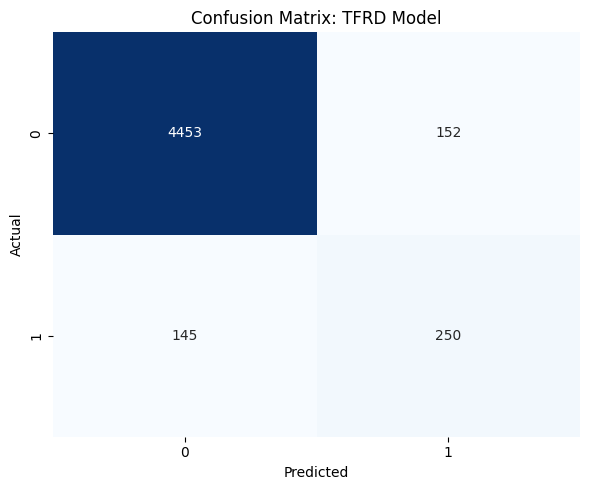

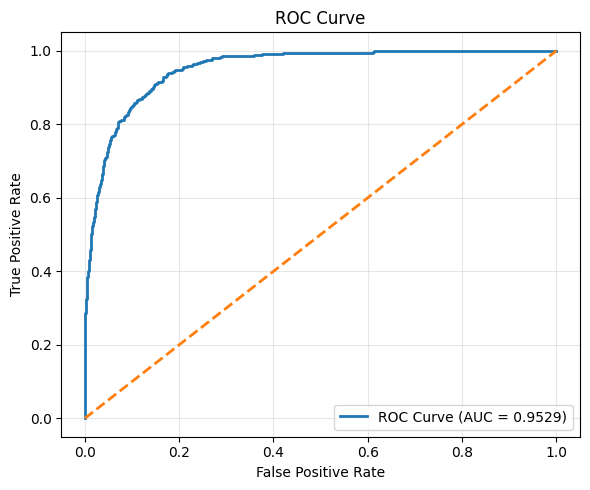

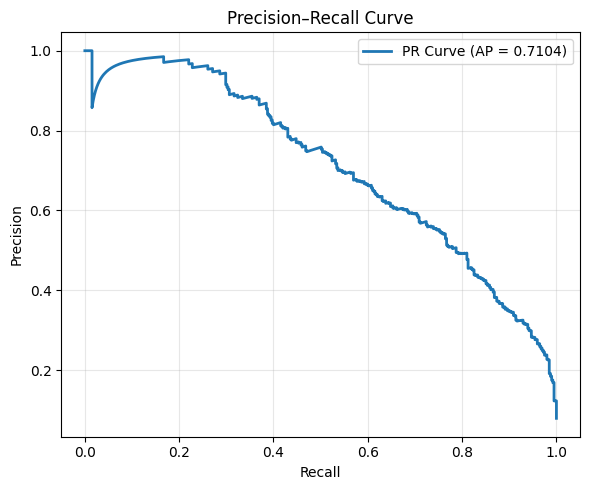

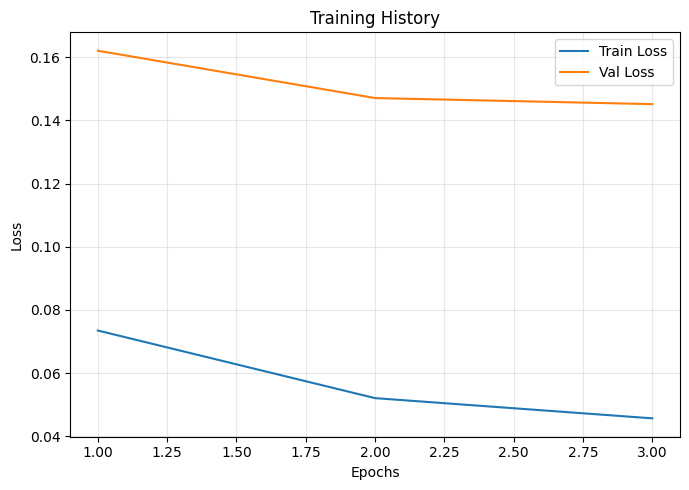


TFRD PIPELINE COMPLETE

Output files:
  - tfrd_best_model.pt (trained model)
  - tfrd_submission.csv (test predictions)
  - confusion_matrix.png
  - roc_curve.png
  - pr_curve.png
  - training_history.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import numpy as np
import torch

def plot_evaluation_metrics(trainer):
    """
    PH-MSA–style Evaluation Plots for TFRD
    --------------------------------------
    1. Classification Report (printed)
    2. Confusion Matrix (heatmap)
    3. ROC Curve (with AUC)
    4. Precision–Recall Curve (with AP)
    5. Training vs Validation Loss
    """

    trainer.student_model.eval()

    # ==========================================================
    # Collect validation predictions (IDENTICAL intent to PH-MSA)
    # ==========================================================
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in trainer.val_loader:
            input_ids = batch['input_ids'].to(trainer.device)
            attention_mask = batch['attention_mask'].to(trainer.device)
            labels = batch['label'].to(trainer.device)

            logits, _ = trainer.student_model(input_ids, attention_mask)
            probs = torch.sigmoid(logits.squeeze(-1))

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)

    # ==========================================================
    # FINAL SUMMARY (Printed ONCE after all epochs)
    # ==========================================================
    print("\n" + "=" * 60)
    print("FINAL VALIDATION PERFORMANCE SUMMARY")
    print("=" * 60)

    print(classification_report(
        all_labels,
        preds,
        target_names=['Non-Toxic', 'Toxic'],
        digits=4
    ))


    # ==========================================================
    # 1. Classification Report
    # ==========================================================
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(
        all_labels, preds,
        target_names=['Non-Toxic', 'Toxic']
    ))

    # ==========================================================
    # 2. Confusion Matrix (PH-MSA style)
    # ==========================================================
    cm = confusion_matrix(all_labels, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', cbar=False
    )
    plt.title('Confusion Matrix: TFRD Model')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()

    # ==========================================================
    # 3. ROC Curve (PH-MSA style)
    # ==========================================================
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr, tpr,
        lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})'
    )
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2)
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300)
    plt.show()

    # ==========================================================
    # 4. Precision–Recall Curve (PH-MSA style)
    # ==========================================================
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    avg_prec = average_precision_score(all_labels, all_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(
        recall, precision,
        lw=2,
        label=f'PR Curve (AP = {avg_prec:.4f})'
    )
    plt.title('Precision–Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('pr_curve.png', dpi=300)
    plt.show()

    # ==========================================================
    # 5. Training History (Loss only — correct for TFRD)
    # ==========================================================
    if hasattr(trainer, 'train_losses') and hasattr(trainer, 'val_losses'):
        epochs = range(1, len(trainer.train_losses) + 1)

        plt.figure(figsize=(7, 5))
        plt.plot(epochs, trainer.train_losses, label='Train Loss')
        plt.plot(epochs, trainer.val_losses, label='Val Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training History')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300)
        plt.show()

def main():
    """Main execution function for TFRD with PH-MSA style evaluation plots"""

    # --------------------------------------------------
    # 1. Initialize configuration
    # --------------------------------------------------
    config = TFRDConfig()

    print("=" * 70)
    print("TFRD: TinyBERT with Fairness-Regularized Distillation")
    print("=" * 70)
    print("\nConfiguration:")
    print(f"  Teacher Model: {config.TEACHER_MODEL}")
    print(f"  Student Model: {config.STUDENT_MODEL}")
    print(f"  Max Length: {config.MAX_LENGTH}")
    print(f"  Batch Size: {config.BATCH_SIZE}")
    print(f"  Learning Rate: {config.LEARNING_RATE}")
    print(f"  Epochs: {config.NUM_EPOCHS}")
    print(f"  Device: {config.DEVICE}")
    print(f"  Temperature: {config.TEMPERATURE}")
    print(f"  Alpha (Task): {config.ALPHA_TASK}")
    print(f"  Alpha (Distill): {config.ALPHA_DISTILL}")
    print(f"  Alpha (Fairness): {config.ALPHA_FAIRNESS}")

    # --------------------------------------------------
    # 2. Initialize trainer
    # --------------------------------------------------
    trainer = TFRDTrainer(config)

    # --------------------------------------------------
    # 3. Load data
    # --------------------------------------------------
    test_df = trainer.load_data()

    # --------------------------------------------------
    # 4. Train model
    # --------------------------------------------------
    trainer.train()

    # --------------------------------------------------
    # 5. Generate predictions (unchanged logic)
    # --------------------------------------------------
    submission = trainer.predict(test_df)

    # --------------------------------------------------
    # 6. PH-MSA style evaluation plots
    # --------------------------------------------------
    plot_evaluation_metrics(trainer)

    print("\n" + "=" * 70)
    print("TFRD PIPELINE COMPLETE")
    print("=" * 70)
    print("\nOutput files:")
    print("  - tfrd_best_model.pt (trained model)")
    print("  - tfrd_submission.csv (test predictions)")
    print("  - confusion_matrix.png")
    print("  - roc_curve.png")
    print("  - pr_curve.png")
    print("  - training_history.png")


if __name__ == "__main__":
    main() 

In [10]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Step 1: recreate trainer and load saved model ────────────────
config = TFRDConfig()
trainer = TFRDTrainer(config)   # this loads tokenizer + models automatically
trainer.load_data()             # this creates val_loader

# load the saved best weights (no retraining)
trainer.student_model.load_state_dict(
    torch.load('/kaggle/working/tfrd_best_model.pt',
               map_location=config.DEVICE)
)
trainer.student_model.eval()

# ── Step 2: fairness function ────────────────────────────────────
def fairness_metrics(y_true, y_prob, identity_mask, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    def rates(yt, yp):
        tn,fp,fn,tp = confusion_matrix(yt,yp,labels=[0,1]).ravel()
        return fp/(fp+tn+1e-9), fn/(fn+tp+1e-9)
    fpr0,fnr0 = rates(y_true[identity_mask==0], y_pred[identity_mask==0])
    fpr1,fnr1 = rates(y_true[identity_mask==1], y_pred[identity_mask==1])
    print(f'FPR non-id:    {fpr0:.3f}')
    print(f'FPR identity:  {fpr1:.3f}')
    print(f'FPR Disparity: {abs(fpr1-fpr0):.3f}')
    print(f'FNR non-id:    {fnr0:.3f}')
    print(f'FNR identity:  {fnr1:.3f}')
    print(f'FNR Disparity: {abs(fnr1-fnr0):.3f}')
    print(f'Eq Odds Gap:   {(abs(fpr1-fpr0)+abs(fnr1-fnr0))/2:.3f}')

# ── Step 3: collect predictions from val_loader ──────────────────
all_probs, all_labels, identity_flags = [], [], []
with torch.no_grad():
    for batch in trainer.val_loader:
        input_ids = batch['input_ids'].to(config.DEVICE)
        attention_mask = batch['attention_mask'].to(config.DEVICE)
        logits, _ = trainer.student_model(input_ids, attention_mask)
        probs = torch.sigmoid(logits.squeeze(-1))
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch['label'].numpy())
        identity_flags.extend(
            (batch['identity'].numpy() >= 0.5).astype(int)
        )

# ── Step 4: print results ─────────────────────────────────────────
fairness_metrics(np.array(all_labels), np.array(all_probs), np.array(identity_flags))

Loading models...

Loading data...
Using sample of 50000 training examples
Training samples: 45000
Validation samples: 5000
Test samples: 97320
FPR non-id:    0.030
FPR identity:  0.066
FPR Disparity: 0.037
FNR non-id:    0.330
FNR identity:  0.480
FNR Disparity: 0.150
Eq Odds Gap:   0.093
